> This script is deigned to be used with conda env
> crime_weather_env

Code to explore the crimetology_NS.parquet file.
Data created via combine_crime_ceda_data.py, spatial_clustering.ipynb

## Import modules

In [62]:
# standard libraries
import os
from pathlib import Path

# other libraries
import duckdb
import matplotlib.pyplot as plt

# typers and submodules
from duckdb import DuckDBPyConnection
from pandas import DataFrame


## Directories, db and Path Setup

In [2]:
cwd: str = os.getcwd()
data_dir: Path = Path(cwd).parent / 'data' / 'police_archives'
crime_db: Path = data_dir/'crime_archive.db'

Connect to the duckdb

In [3]:
con: DuckDBPyConnection = duckdb.connect(database=crime_db)

Introspect

In [4]:
# introspect
con.execute(query="SHOW TABLES").fetchall()

[('crimetology_NS',),
 ('crimetology_NS_clean',),
 ('crimetology_coords_lookup',),
 ('street_data',)]

In [5]:
con.execute(query="SELECT * FROM crimetology_NS_clean LIMIT 5;").df()


,Crime ID,Month,Longitude,Latitude,Crime type,tasmax,tas,groundfrost,sun,snowLying,tasmin,rainfall,hurs,sfcWind,Cluster ID
0,00926dfc98a1ad484fec277ced4f0237c1032d9d63f4f0...,2020-01,0.521596,52.345789,Violence and sexual offences,9.597225,6.834480,8.521248,57.155247,0.028889,4.043394,46.032112,88.652786,4.317238,869
1,08088ddb322e7dfb2bc9eb9736776849fa6e6568e28725...,2020-01,1.188665,52.041702,Violence and sexual offences,9.253441,6.699946,12.421773,53.776817,0.017040,4.145340,42.233070,88.948593,4.330167,5065
2,3bb04e754be52c4b474e9a5d5cba723cb44063d592348f...,2020-01,0.392886,52.245956,Burglary,9.339664,6.674413,8.760840,60.050930,0.054434,3.973928,49.437729,89.399498,4.221702,289
3,975d8b78c0b49bce0c2bda4b15770a7b29bdd55ddc62cd...,2020-01,0.694570,52.259155,Violence and sexual offences,9.237802,6.624474,8.096927,60.260311,0.116909,4.029425,52.358356,89.107567,4.471696,1703
4,becd00d626e8dfc23c780e8238961dc788183688b3b92b...,2020-01,1.335191,51.965723,Violence and sexual offences,9.293962,7.044072,6.509821,56.745304,0.000000,4.690509,31.948408,88.402222,5.864347,7123


This looks good

## Set up crime typology buckets

In [19]:
crime_categories: DataFrame = con.execute(query="""SELECT DISTINCT "Crime type" FROM crimetology_NS_clean""").df()


In [20]:
crime_categories

,Crime type
0,Drugs
1,Shoplifting
2,Robbery
3,Vehicle crime
4,Burglary
5,Other crime
6,Violence and sexual offences
7,Theft from the person
8,Public order
9,Other theft


In [37]:
leisure_zone_typology: list[str] = ['Anti-social behaviour',
                                  'Criminal damage and arson',
                                  'Public order',
                                  'Vehicle crime',
                                  'Drugs']

leisure_str: str = ", ".join(f"'{c}'" for c in leisure_zone_typology)

In [38]:
commercial_zone_typology: list[str] = ['Other theft', 
                                     'Robbery', 
                                     'Shoplifting']

commercial_str: str = ", ".join(f"'{c}'" for c in commercial_zone_typology)

In [43]:
cluster_classification_query = f"""SELECT "Cluster ID",
                                          "Crime type",
                                   CASE 
                                     WHEN "Crime type" IN ({leisure_str}) THEN 'Leisure'
                                     WHEN "Crime type" IN ({commercial_str}) THEN 'Retail'
                                     ELSE 'OTHER'
                                   END AS crime_bucket
                                   FROM crimetology_NS_clean
                                   WHERE "Cluster ID" != -1       -- Ignore noise points
                                   """

In [45]:
event_level_typology: DataFrame = con.execute(query=cluster_classification_query).df()

In [46]:
event_level_typology

,Cluster ID,Crime type,crime_bucket
0,7424,Violence and sexual offences,OTHER
1,6015,Violence and sexual offences,OTHER
2,6015,Violence and sexual offences,OTHER
3,2986,Violence and sexual offences,OTHER
4,5556,Violence and sexual offences,OTHER
...,...,...,...
1254382,8411,Violence and sexual offences,OTHER
1254383,318,Violence and sexual offences,OTHER
1254384,6015,Public order,Leisure
1254385,5140,Other crime,OTHER


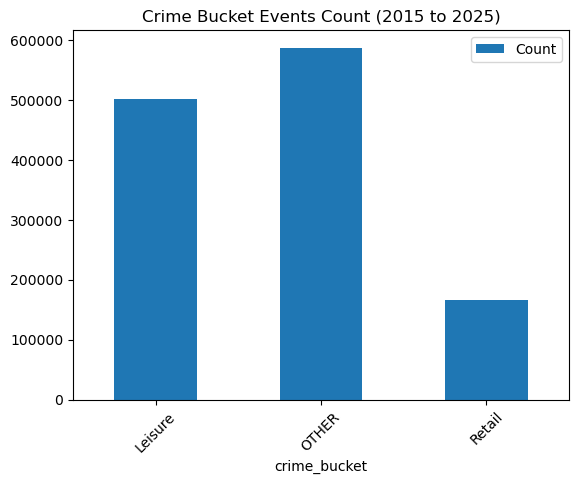

In [67]:
event_level_typology.groupby(by='crime_bucket').agg(func='count').reset_index()[['crime_bucket','Cluster ID']].rename(columns = {'Cluster ID':'Count'}).plot.bar(x='crime_bucket',y='Count',rot=45)
plt.title(label='Crime Bucket Events Count (2015 to 2025)')
plt.show()